In [1]:
!pip install requests pandas yfinance matplotlib

In [2]:
import requests
import pandas as pd
import yfinance as yf
from pandas import json_normalize
import matplotlib.pyplot as plt

In [4]:
from datetime import datetime, timedelta

end_date = datetime.today().date()
start_date = end_date - timedelta(days=90)

url = f"https://api.frankfurter.app/{start_date}..{end_date}"

params = {
    "from": "USD",
    "to": "INR"
}

response = requests.get(url, params=params)
print("Status Code:", response.status_code)

data = response.json()
print(data)

Status Code: 200
{'amount': 1.0, 'base': 'USD', 'start_date': '2026-04-02', 'end_date': '2026-07-01', 'rates': {'2026-04-02': {'INR': 93.1}, '2026-04-07': {'INR': 93.01}, '2026-04-08': {'INR': 92.22}, '2026-04-09': {'INR': 92.66}, '2026-04-10': {'INR': 92.89}, '2026-04-13': {'INR': 93.33}, '2026-04-14': {'INR': 93.09}, '2026-04-15': {'INR': 93.44}, '2026-04-16': {'INR': 93.24}, '2026-04-17': {'INR': 92.82}, '2026-04-20': {'INR': 93.07}, '2026-04-21': {'INR': 93.51}, '2026-04-22': {'INR': 93.8}, '2026-04-23': {'INR': 94.11}, '2026-04-24': {'INR': 94.25}, '2026-04-27': {'INR': 94.2}, '2026-04-28': {'INR': 94.55}, '2026-04-29': {'INR': 94.85}, '2026-04-30': {'INR': 94.92}, '2026-05-04': {'INR': 95.09}, '2026-05-05': {'INR': 95.28}, '2026-05-06': {'INR': 94.62}, '2026-05-07': {'INR': 94.26}, '2026-05-08': {'INR': 94.49}, '2026-05-11': {'INR': 95.32}, '2026-05-12': {'INR': 95.64}, '2026-05-13': {'INR': 95.67}, '2026-05-14': {'INR': 95.77}, '2026-05-15': {'INR': 95.97}, '2026-05-18': {'INR':

In [5]:
exchange_df = (
    pd.DataFrame(data["rates"])
      .T
      .reset_index()
)

exchange_df.columns = ["Date", "USD_INR"]
exchange_df["Date"] = pd.to_datetime(exchange_df["Date"])
exchange_df.head()

,Date,USD_INR
0,2026-04-02,93.10
1,2026-04-07,93.01
2,2026-04-08,92.22
3,2026-04-09,92.66
4,2026-04-10,92.89


In [7]:
stock_df = yf.download(
    "RELIANCE.NS",
    start="2023-01-01",
    end="2024-01-01"
)

stock_df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1170.477905,1171.886546,1157.891121,1158.709022,5316175
2023-01-03,1161.912354,1169.160003,1157.709267,1165.547536,7658932
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687,9264891
2023-01-05,1142.373535,1152.529332,1137.806870,1146.667607,13637099
2023-01-06,1152.756226,1157.777333,1144.304501,1148.098697,6349597


In [14]:
stock_df = stock_df.reset_index()
stock_df.head()

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,0,2023-01-02,1170.477905,1171.886546,1157.891121,1158.709022,5316175
1,1,2023-01-03,1161.912354,1169.160003,1157.709267,1165.547536,7658932
2,2,2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687,9264891
3,3,2023-01-05,1142.373535,1152.529332,1137.806870,1146.667607,13637099
4,4,2023-01-06,1152.756226,1157.777333,1144.304501,1148.098697,6349597


In [15]:
retail_df = pd.DataFrame({

    "Date":[
        "2026-04-10",
        "2026-04-20",
        "2026-05-05",
        "2026-05-22",
        "2026-06-15"
    ],

    "Revenue_USD":[
        120,
        340,
        450,
        280,
        600
    ]

})

retail_df["Date"] = pd.to_datetime(retail_df["Date"])

retail_df

,Date,Revenue_USD
0,2026-04-10,120
1,2026-04-20,340
2,2026-05-05,450
3,2026-05-22,280
4,2026-06-15,600


In [11]:
merged_df["Revenue_INR"] = (merged_df["Revenue_USD"]*merged_df["USD_INR"])
merged_df

,Date,Revenue_USD,USD_INR,Revenue_INR
0,2026-04-10,120,92.89,11146.8
1,2026-04-20,340,93.07,31643.8
2,2026-05-05,450,95.28,42876.0
3,2026-05-22,280,95.70,26796.0
4,2026-06-15,600,94.72,56832.0


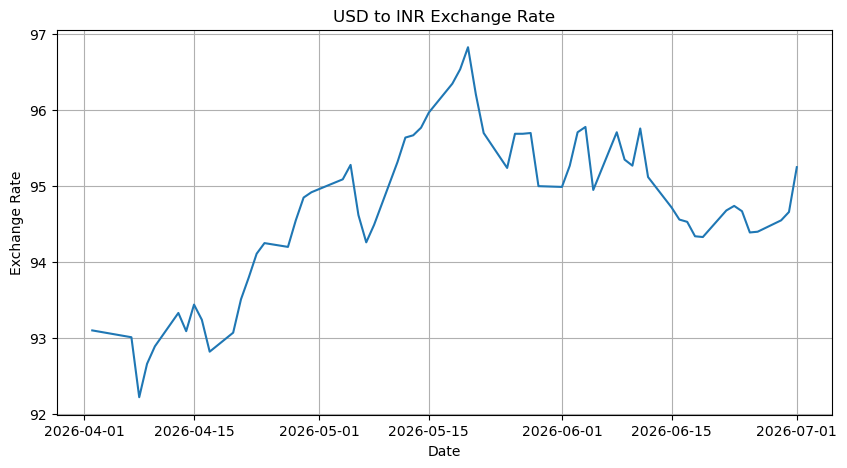

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    exchange_df["Date"],
    exchange_df["USD_INR"]
)

plt.title("USD to INR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.show()